In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = '/content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1'
HOSP_PATH   = f'{BASE_PATH}/hosp'
ICU_PATH    = f'{BASE_PATH}/icu'
OUTPUT_PATH = f'{BASE_PATH}/fl_clients'

os.makedirs(OUTPUT_PATH, exist_ok=True)
print("Setup done ✓")

Mounted at /content/drive
Setup done ✓


In [2]:
print("Loading core tables...")

admissions = pd.read_csv(f'{HOSP_PATH}/admissions.csv.gz',
                         compression='gzip',
                         usecols=['subject_id','hadm_id',
                                  'hospital_expire_flag',
                                  'insurance','race',
                                  'admittime','dischtime',
                                  'admission_type'])

patients = pd.read_csv(f'{HOSP_PATH}/patients.csv.gz',
                       compression='gzip',
                       usecols=['subject_id','anchor_age','gender'])

icustays = pd.read_csv(f'{ICU_PATH}/icustays.csv.gz',
                       compression='gzip',
                       usecols=['subject_id','hadm_id','stay_id',
                                'first_careunit','last_careunit','los'])

# Merge into master
df = icustays.merge(admissions, on=['subject_id','hadm_id'])
df = df.merge(patients, on='subject_id')
df['mortality'] = df['hospital_expire_flag'].astype(int)

# Encode demographics
df['gender_enc']         = (df['gender'] == 'M').astype(int)
df['insurance_enc']      = df['insurance'].astype('category').cat.codes
df['race_enc']           = df['race'].astype('category').cat.codes
df['admission_type_enc'] = df['admission_type'].astype('category').cat.codes

print(f"Master shape     : {df.shape}")
print(f"Mortality rate   : {df['mortality'].mean()*100:.1f}%")
print(f"\nCare units:\n{df['first_careunit'].value_counts()}")

Loading core tables...
Master shape     : (94458, 19)
Mortality rate   : 12.0%

Care units:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                         10
Medicine/Cardiology Intermediate                        1
Med/Surg               

In [3]:
LAB_ITEMIDS = {
    50809: 'glucose_bg',    50811: 'hemoglobin_bg', 50813: 'lactate',
    50820: 'pH',            50861: 'ALT',            50862: 'albumin',
    50878: 'AST',           50882: 'bicarbonate',    50885: 'bilirubin_total',
    50893: 'calcium',       50902: 'chloride',       50912: 'creatinine',
    50931: 'glucose',       50960: 'magnesium',      50971: 'potassium',
    50983: 'sodium',        51003: 'troponin_T',     51006: 'BUN',
    51221: 'hematocrit',    51222: 'hemoglobin',     51237: 'INR',
    51265: 'platelet',      51275: 'PTT',            51301: 'WBC',
}

valid_hadm_ids = set(df['hadm_id'].unique())
stats = defaultdict(lambda: [0.0, 0.0, np.inf, -np.inf, 0, 0, 0])

print("Streaming labevents (~10-12 min)...")
i = 0
for chunk in pd.read_csv(
        f'{HOSP_PATH}/labevents.csv-003.gz',
        compression='gzip',
        chunksize=200_000,
        usecols=['hadm_id','itemid','valuenum','flag','priority']):

    chunk = chunk[
        chunk['itemid'].isin(LAB_ITEMIDS.keys()) &
        chunk['hadm_id'].isin(valid_hadm_ids) &
        chunk['valuenum'].notna()
    ].copy()

    if len(chunk) == 0:
        i += 1
        continue

    chunk['lab_name']    = chunk['itemid'].map(LAB_ITEMIDS)
    chunk['is_abnormal'] = chunk['flag'].notna().astype(int)
    chunk['is_stat']     = (chunk['priority'] == 'STAT').astype(int)

    for (hadm_id, lab_name), grp in chunk.groupby(['hadm_id','lab_name']):
        key  = (hadm_id, lab_name)
        vals = grp['valuenum'].values
        stats[key][0] += vals.sum()
        stats[key][1] += (vals ** 2).sum()
        stats[key][2]  = min(stats[key][2], vals.min())
        stats[key][3]  = max(stats[key][3], vals.max())
        stats[key][4] += len(vals)
        stats[key][5] += int(grp['is_abnormal'].sum())
        stats[key][6] += int(grp['is_stat'].sum())

    i += 1
    if i % 10 == 0:
        print(f"  Chunk {i} done...", end='\r')

print(f"\nDone. Pairs: {len(stats):,}")

rows = []
for (hadm_id, lab_name), s in stats.items():
    n        = s[4]
    mean_val = s[0] / n
    std_val  = np.sqrt(max(s[1]/n - mean_val**2, 0))
    rows.append({
        'hadm_id'   : hadm_id,
        'lab_name'  : lab_name,
        'mean_val'  : mean_val,
        'min_val'   : s[2],
        'max_val'   : s[3],
        'std_val'   : std_val,
        'n_measured': n,
        'n_abnormal': s[5],
        'n_stat'    : s[6],
    })

agg = pd.DataFrame(rows)
lab_pivot = agg.pivot_table(
    index   = 'hadm_id',
    columns = 'lab_name',
    values  = ['mean_val','min_val','max_val','std_val',
               'n_measured','n_abnormal','n_stat']
)
lab_pivot.columns  = [f'lab_{v}_{c}' for v, c in lab_pivot.columns]
lab_pivot          = lab_pivot.reset_index()

df = df.merge(lab_pivot, on='hadm_id', how='left')
print(f"Master shape after labs: {df.shape}")
print(f"Lab columns: {len([c for c in df.columns if c.startswith('lab_')])}")

Streaming labevents (~10-12 min)...

Done. Pairs: 1,659,587
Master shape after labs: (94458, 187)
Lab columns: 168


In [4]:
# 14 core ICU vitals — clinically meaningful for mortality
VITAL_ITEMIDS = {
    220045: 'heart_rate',
    220179: 'sbp',              # systolic BP non-invasive
    220180: 'dbp',              # diastolic BP non-invasive
    220052: 'sbp_invasive',     # arterial line systolic
    220050: 'dbp_invasive',     # arterial line diastolic
    220181: 'map',              # mean arterial pressure
    220210: 'resp_rate',
    220277: 'spo2',
    223762: 'temp_celsius',
    220739: 'gcs_eye',
    223900: 'gcs_verbal',
    223901: 'gcs_motor',
    223835: 'fio2',             # fraction of inspired O2
    224700: 'peep',             # ventilator pressure
}

valid_stay_ids = set(df['stay_id'].unique())
vstats = defaultdict(lambda: [0.0, 0.0, np.inf, -np.inf, 0, 0])

print("Streaming chartevents (~15-18 min)...")
i = 0
for chunk in pd.read_csv(
        f'{ICU_PATH}/chartevents.csv-002.gz',
        compression='gzip',
        chunksize=200_000,
        usecols=['stay_id','itemid','valuenum','warning']):

    chunk = chunk[
        chunk['itemid'].isin(VITAL_ITEMIDS.keys()) &
        chunk['stay_id'].isin(valid_stay_ids) &
        chunk['valuenum'].notna()
    ].copy()

    if len(chunk) == 0:
        i += 1
        continue

    chunk['vital_name'] = chunk['itemid'].map(VITAL_ITEMIDS)
    chunk['is_warning'] = chunk['warning'].fillna(0).astype(int)

    for (stay_id, vital_name), grp in chunk.groupby(['stay_id','vital_name']):
        key  = (stay_id, vital_name)
        vals = grp['valuenum'].values
        vstats[key][0] += vals.sum()
        vstats[key][1] += (vals ** 2).sum()
        vstats[key][2]  = min(vstats[key][2], vals.min())
        vstats[key][3]  = max(vstats[key][3], vals.max())
        vstats[key][4] += len(vals)
        vstats[key][5] += int(grp['is_warning'].sum())

    i += 1
    if i % 20 == 0:
        print(f"  Chunk {i} done...", end='\r')

print(f"\nDone. Pairs: {len(vstats):,}")

vrows = []
for (stay_id, vital_name), s in vstats.items():
    n        = s[4]
    mean_val = s[0] / n
    std_val  = np.sqrt(max(s[1]/n - mean_val**2, 0))
    vrows.append({
        'stay_id'   : stay_id,
        'vital_name': vital_name,
        'mean_val'  : mean_val,
        'min_val'   : s[2],
        'max_val'   : s[3],
        'std_val'   : std_val,
        'n_measured': n,
        'n_warning' : s[5],
    })

vagg = pd.DataFrame(vrows)
vitals_pivot = vagg.pivot_table(
    index   = 'stay_id',
    columns = 'vital_name',
    values  = ['mean_val','min_val','max_val','std_val',
               'n_measured','n_warning']
)
vitals_pivot.columns = [f'vital_{v}_{c}' for v, c in vitals_pivot.columns]
vitals_pivot         = vitals_pivot.reset_index()

df = df.merge(vitals_pivot, on='stay_id', how='left')
print(f"Master shape after vitals: {df.shape}")
print(f"Vital columns: {len([c for c in df.columns if c.startswith('vital_')])}")

Streaming chartevents (~15-18 min)...

Done. Pairs: 1,003,610
Master shape after vitals: (94458, 271)
Vital columns: 84


In [5]:
print("Loading outputevents...")

URINE_ITEMIDS = [226559,226560,226561,226584,226563,
                 226564,226565,226567,226557,226558]

outputevents = pd.read_csv(f'{ICU_PATH}/outputevents.csv.gz',
                            compression='gzip',
                            usecols=['stay_id','itemid','value'])

urine = outputevents[outputevents['itemid'].isin(URINE_ITEMIDS)]
urine_agg = urine.groupby('stay_id')['value'].agg(
    urine_total = 'sum',
    urine_mean  = 'mean',
    urine_count = 'count',
).reset_index()

df = df.merge(urine_agg, on='stay_id', how='left')
df['urine_total'] = df['urine_total'].fillna(0)
df['urine_mean']  = df['urine_mean'].fillna(0)
df['urine_count'] = df['urine_count'].fillna(0)

print(f"Master shape after urine: {df.shape}")

Loading outputevents...
Master shape after urine: (94458, 274)


In [6]:
print("Loading inputevents (vasopressors)...")

# Key vasopressor itemids in MIMIC-IV
VASOPRESSOR_ITEMIDS = {
    221906: 'norepinephrine',
    221289: 'epinephrine',
    222315: 'vasopressin',
    221749: 'phenylephrine',
    221662: 'dopamine',
}

inputevents = pd.read_csv(f'{ICU_PATH}/inputevents.csv.gz',
                           compression='gzip',
                           usecols=['stay_id','itemid','amount'])

vasopressors = inputevents[inputevents['itemid'].isin(VASOPRESSOR_ITEMIDS.keys())].copy()
vasopressors['vaso_name'] = vasopressors['itemid'].map(VASOPRESSOR_ITEMIDS)

# Binary flag per patient — did they receive this vasopressor?
vaso_pivot = vasopressors.groupby(['stay_id','vaso_name'])['amount'].sum().unstack(fill_value=0)
vaso_pivot.columns = [f'vaso_{c}' for c in vaso_pivot.columns]

# Convert to binary (1 = received, 0 = not)
for col in vaso_pivot.columns:
    vaso_pivot[col] = (vaso_pivot[col] > 0).astype(int)

vaso_pivot = vaso_pivot.reset_index()

df = df.merge(vaso_pivot, on='stay_id', how='left')
# Fill missing with 0 (patient never received that vasopressor)
for col in [c for c in df.columns if c.startswith('vaso_')]:
    df[col] = df[col].fillna(0).astype(int)

print(f"Master shape after vasopressors: {df.shape}")
print(f"Vasopressor columns: {[c for c in df.columns if c.startswith('vaso_')]}")

Loading inputevents (vasopressors)...
Master shape after vasopressors: (94458, 279)
Vasopressor columns: ['vaso_dopamine', 'vaso_epinephrine', 'vaso_norepinephrine', 'vaso_phenylephrine', 'vaso_vasopressin']


In [7]:
# Cache the fully-merged master table.
# Cells 1-5 stream labevents + chartevents and take ~30 min. Everything below
# (partition / plots / export) is cheap and will be re-run several times with
# different SPLIT_SCHEME / DROP_LOS settings — cache here so those re-runs cost
# seconds instead of half an hour.
CACHE_PATH = f'{BASE_PATH}/master_df.parquet'

# --- First run: save the cache -------------------------------------------
df.to_parquet(CACHE_PATH, index=False)
print(f"Cached master table -> {CACHE_PATH}   shape={df.shape}")

# --- Later runs: skip cells 1-5 entirely and uncomment these two lines ----
# df = pd.read_parquet(CACHE_PATH)
# print(f"Loaded master table from cache   shape={df.shape}")

Cached master table -> /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/master_df.parquet   shape=(94458, 279)


In [8]:
# ---------------------------------------------------------------------------
# Client partition.
#
# SPLIT_SCHEME switches between the original 3-silo partition (paper main
# results) and a 6-silo partition with one client per major ICU care unit.
#
# Why n=6 matters: Krum's Byzantine-resilience condition is n >= 2f+3, so at
# n=3, f=1 it is outside its own guarantee (k = n-f-2 = 0 gets clamped to 1,
# honest clients' scores tie bit-identically, and the "winner" is decided by
# submission order). At n=6, f=1 -> k=3 and Krum runs in its valid regime.
# Coordinate-wise trimmed mean also becomes meaningful: floor(0.2*n) is 0 at
# n=3 (trims nothing) but 1 at n=6.
#
# Nothing here mutates `df`, so the cell is safe to re-run with either scheme.
# ---------------------------------------------------------------------------
SPLIT_SCHEME = 'six'      # 'three' | 'six'
DROP_LOS     = True       # los is only known at discharge -> leaks the label
KEEP_ID_COLS = False      # see note in the export cell before enabling

SPLIT_SCHEMES = {
    # Original partition: 8 care units folded into 3 silos.
    # Note this puts 7,197 neuro stays inside the "cardiac" client.
    'three': [
        (0, 'medical',  ['Medical Intensive Care Unit (MICU)',
                         'Medical/Surgical Intensive Care Unit (MICU/SICU)']),
        (1, 'surgical', ['Surgical Intensive Care Unit (SICU)',
                         'Trauma SICU (TSICU)']),
        (2, 'cardiac',  ['Coronary Care Unit (CCU)',
                         'Cardiac Vascular Intensive Care Unit (CVICU)',
                         'Neuro Intermediate',
                         'Neuro Stepdown']),
    ],
    # One silo per major ICU care unit. Sizes stay in a 10.5k-20.7k band, so no
    # client is degenerate, and each silo is now a single clinically coherent
    # unit rather than a merge.
    'six': [
        (0, 'micu',    ['Medical Intensive Care Unit (MICU)']),
        (1, 'medsurg', ['Medical/Surgical Intensive Care Unit (MICU/SICU)']),
        (2, 'sicu',    ['Surgical Intensive Care Unit (SICU)']),
        (3, 'tsicu',   ['Trauma SICU (TSICU)']),
        (4, 'ccu',     ['Coronary Care Unit (CCU)']),
        (5, 'cvicu',   ['Cardiac Vascular Intensive Care Unit (CVICU)']),
    ],
}

CLIENT_SPECS = SPLIT_SCHEMES[SPLIT_SCHEME]
N_CLIENTS    = len(CLIENT_SPECS)
client_map   = {unit: cid for cid, _, units in CLIENT_SPECS for unit in units}
client_names = {cid: name for cid, name, _ in CLIENT_SPECS}
mapped_units = list(client_map)

# Build the partition on a copy so `df` stays intact across re-runs.
keep     = df['first_careunit'].isin(mapped_units)
df_split = df[keep].copy()
df_split['client_id'] = df_split['first_careunit'].map(client_map).astype(int)

dropped = df.loc[~keep, 'first_careunit'].value_counts()
if len(dropped):
    print(f"Unmapped care units (dropped, {dropped.sum():,} stays):")
    for unit, n in dropped.items():
        print(f"    {unit:<52} {n:>6,}")

clients = [df_split[df_split['client_id'] == cid].reset_index(drop=True)
           for cid, _, _ in CLIENT_SPECS]

print(f"\nScheme '{SPLIT_SCHEME}' -> {N_CLIENTS} clients, {len(df_split):,} stays retained")
print(f"{'Client':<20} {'Stays':>8} {'Mortality':>11}")
print('-' * 41)
for (cid, name, _), c in zip(CLIENT_SPECS, clients):
    print(f"{f'client{cid}_{name}':<20} {len(c):>8,} "
          f"{c['mortality'].mean()*100:>10.1f}%")

Unmapped care units (dropped, 9,277 stays):
    Neuro Intermediate                                    5,776
    Neuro Surgical Intensive Care Unit (Neuro SICU)       1,751
    Neuro Stepdown                                        1,421
    Surgery/Vascular/Intermediate                           145
    PACU                                                    122
    Intensive Care Unit (ICU)                                33
    Medicine                                                 16
    Surgery/Trauma                                           10
    Medicine/Cardiology Intermediate                          1
    Med/Surg                                                  1
    Neurology                                                 1

Scheme 'six' -> 6 clients, 85,181 stays retained
Client                  Stays   Mortality
-----------------------------------------
client0_micu           20,703       16.6%
client1_medsurg        15,449       15.5%
client2_sicu           13,009     


Client                   Size  Mortality%   Avg Age   Avg LOS    Vaso%
--------------------------------------------------------------------
client0_micu           20,703       16.6%      61.5      3.76    27.8%
client1_medsurg        15,449       15.5%      62.1      3.09    21.9%
client2_sicu           13,009       11.9%      61.9      3.90    22.1%
client3_tsicu          10,474       11.0%      60.2      3.64    24.7%
client4_ccu            10,775       13.7%      67.7      3.09    26.7%
client5_cvicu          14,771        4.4%      66.2      3.32    58.7%


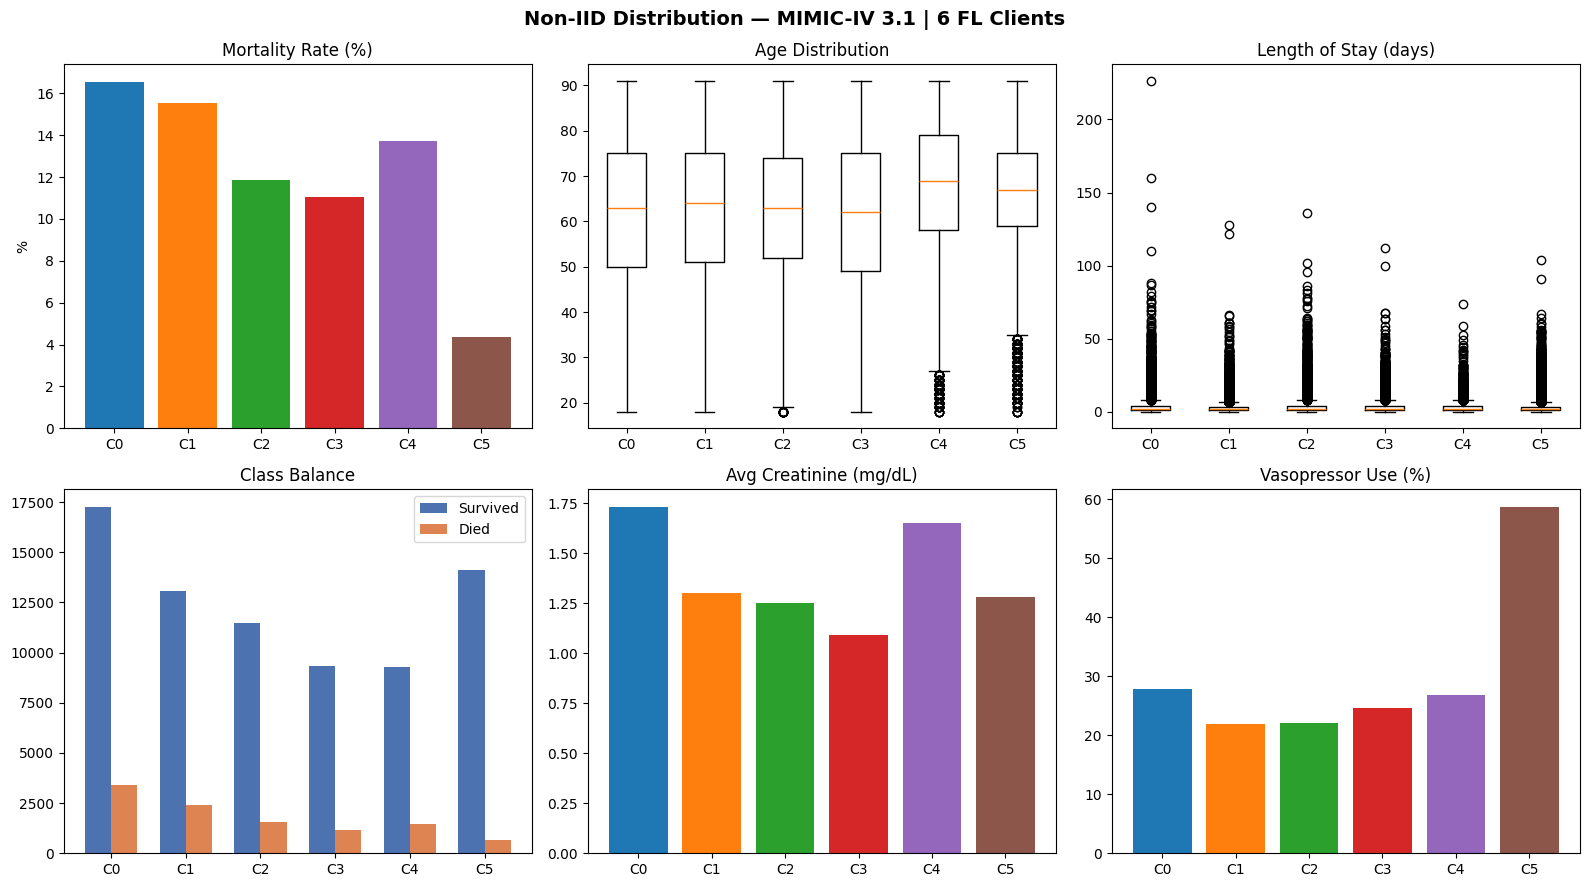

Plot saved ✓


In [9]:
short  = [f'C{cid}' for cid, _, _ in CLIENT_SPECS]
labels = [f'C{cid}\n({name})' for cid, name, _ in CLIENT_SPECS]
colors = plt.cm.tab10(np.arange(N_CLIENTS) % 10)

vaso_cols = [c for c in df_split.columns if c.startswith('vaso_')]

print(f"\n{'Client':<20} {'Size':>8} {'Mortality%':>11} {'Avg Age':>9} "
      f"{'Avg LOS':>9} {'Vaso%':>8}")
print('-' * 68)
for (cid, name, _), c in zip(CLIENT_SPECS, clients):
    vaso_any = (c[vaso_cols].sum(axis=1) > 0).mean() * 100 if vaso_cols else 0
    print(f"{f'client{cid}_{name}':<20} {len(c):>8,} "
          f"{c['mortality'].mean()*100:>10.1f}% "
          f"{c['anchor_age'].mean():>9.1f} "
          f"{c['los'].mean():>9.2f} "
          f"{vaso_any:>7.1f}%")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Non-IID Distribution — MIMIC-IV 3.1 | {N_CLIENTS} FL Clients',
             fontsize=14, fontweight='bold')

# Mortality rate
axes[0,0].bar(short, [c['mortality'].mean()*100 for c in clients], color=colors)
axes[0,0].set_title('Mortality Rate (%)')
axes[0,0].set_ylabel('%')

# Age
axes[0,1].boxplot([c['anchor_age'].dropna().values for c in clients], labels=short)
axes[0,1].set_title('Age Distribution')

# LOS
axes[0,2].boxplot([c['los'].dropna().values for c in clients], labels=short)
axes[0,2].set_title('Length of Stay (days)')

# Class balance
x, w = np.arange(N_CLIENTS), 0.35
axes[1,0].bar(x-w/2, [(c['mortality']==0).sum() for c in clients],
              w, label='Survived', color='#4C72B0')
axes[1,0].bar(x+w/2, [(c['mortality']==1).sum() for c in clients],
              w, label='Died',     color='#DD8452')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(short)
axes[1,0].set_title('Class Balance')
axes[1,0].legend()

# Creatinine
if 'lab_mean_val_creatinine' in df_split.columns:
    axes[1,1].bar(short, [c['lab_mean_val_creatinine'].mean() for c in clients],
                  color=colors)
    axes[1,1].set_title('Avg Creatinine (mg/dL)')

# Vasopressor usage
if vaso_cols:
    axes[1,2].bar(short, [(c[vaso_cols].sum(axis=1) > 0).mean()*100 for c in clients],
                  color=colors)
    axes[1,2].set_title('Vasopressor Use (%)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/noniid_validation_n{N_CLIENTS}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

In [10]:
# Columns to EXCLUDE from features (IDs, labels, raw strings)
EXCLUDE_COLS = [
    'subject_id', 'hadm_id', 'stay_id',
    'hospital_expire_flag', 'mortality',   # labels
    'first_careunit', 'last_careunit',     # strings
    'gender', 'insurance', 'race',         # raw strings (encoded versions kept)
    'admission_type',                      # raw string (encoded version kept)
    'admittime', 'dischtime',              # timestamps
    'client_id',
]
if DROP_LOS:
    # Length of stay is only known at discharge and is strongly coupled to
    # in-hospital death — keeping it as an input leaks the label.
    EXCLUDE_COLS.append('los')

# NOTE: enabling KEEP_ID_COLS writes subject_id/hadm_id/stay_id into the CSVs so
# you can do a group-aware (patient-level) train/val/test split. src/sfl/client/
# dataset.py treats *every* non-target column as a feature, so it must be taught
# to skip them before you turn this on:
#     ID_COLS = {'subject_id', 'hadm_id', 'stay_id'}
#     feature_cols = [c for c in df.columns if c != target_col and c not in ID_COLS]
ID_COLS = ['subject_id', 'hadm_id', 'stay_id'] if KEEP_ID_COLS else []


def get_feature_cols(client_df):
    return [c for c in client_df.columns
            if c not in EXCLUDE_COLS
            and client_df[c].dtype in ['float64', 'float32', 'int64', 'int32', 'int8']]


feature_cols = get_feature_cols(clients[0])
INPUT_DIM = len(feature_cols)

print(f"Total feature columns : {INPUT_DIM}   (los {'DROPPED' if DROP_LOS else 'kept'})")
print(f"\nFeature breakdown:")
for prefix, label in [('lab_', 'Lab features   '), ('vital_', 'Vital features '),
                      ('urine_', 'Urine features '), ('vaso_', 'Vaso features  ')]:
    print(f"  {label}   : {len([c for c in feature_cols if c.startswith(prefix)])}")
print(f"  Demographic feats : "
      f"{len([c for c in feature_cols if not any(c.startswith(p) for p in ['lab_','vital_','urine_','vaso_'])])}")

# Write each client to a scheme-specific folder so the 3-client CSVs backing the
# current paper results are never overwritten.
OUT_DIR = f'{OUTPUT_PATH}' if SPLIT_SCHEME == 'three' else f'{OUTPUT_PATH}_n{N_CLIENTS}'
os.makedirs(OUT_DIR, exist_ok=True)

print(f"\nSaving to {OUT_DIR} ...")
for (cid, name, _), client_df in zip(CLIENT_SPECS, clients):
    fname     = f'client{cid}_{name}'
    feat_cols = get_feature_cols(client_df)
    assert len(feat_cols) == INPUT_DIM, f'{fname}: {len(feat_cols)} != {INPUT_DIM}'
    save_df   = client_df[ID_COLS + feat_cols + ['mortality']].copy()
    save_df   = save_df.fillna(0)
    save_df.to_csv(f'{OUT_DIR}/{fname}.csv', index=False)
    print(f"  {fname}: {len(save_df):,} rows x {len(feat_cols)} features -> saved ✓")

summary = pd.DataFrame({
    'client'        : [f'client{cid}_{name}' for cid, name, _ in CLIENT_SPECS],
    'n_stays'       : [len(c) for c in clients],
    'n_positive'    : [int(c['mortality'].sum()) for c in clients],
    'mortality_pct' : [round(c['mortality'].mean()*100, 2) for c in clients],
    'avg_age'       : [round(c['anchor_age'].mean(), 1) for c in clients],
    'avg_los_days'  : [round(c['los'].mean(), 2) for c in clients],
    'n_features'    : [len(get_feature_cols(c)) for c in clients],
})
summary.to_csv(f'{OUT_DIR}/split_summary.csv', index=False)
print(f"\nSummary saved ✓\n")
print(summary.to_string(index=False))

# ---------------------------------------------------------------------------
# Config scaffolding — paste these into the repo.
# ---------------------------------------------------------------------------
print(f"\n\n{'='*70}\nconfigs/server.yaml — set these two keys:\n{'='*70}")
print(f"expected_num_clients: {N_CLIENTS}")
print(f"input_dim: {INPUT_DIM}")

print(f"\n{'='*70}\nconfigs/clients/client{{id}}_{{name}}.yaml — one file each:\n{'='*70}")
for cid, name, _ in CLIENT_SPECS:
    print(f"""
# --- configs/clients/client{cid}_{name}.yaml ---
client_id: {cid}
client_name: {name}
data_path: data/processed/client{cid}_{name}.csv
model_dir: models/client{cid}_{name}
results_dir: results/label_private_splitfed/client{cid}_{name}
target_col: mortality
batch_size: 64
lr_encoder: 0.0001
weight_decay: 0.001
seed: 42
input_dim: {INPUT_DIM}
encoder_hidden_dim: 64
max_pos_weight: 5.0""".rstrip())

Total feature columns : 265   (los DROPPED)

Feature breakdown:
  Lab features      : 168
  Vital features    : 84
  Urine features    : 3
  Vaso features     : 5
  Demographic feats : 5

Saving to /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/fl_clients_n6 ...
  client0_micu: 20,703 rows x 265 features -> saved ✓
  client1_medsurg: 15,449 rows x 265 features -> saved ✓
  client2_sicu: 13,009 rows x 265 features -> saved ✓
  client3_tsicu: 10,474 rows x 265 features -> saved ✓
  client4_ccu: 10,775 rows x 265 features -> saved ✓
  client5_cvicu: 14,771 rows x 265 features -> saved ✓

Summary saved ✓

         client  n_stays  n_positive  mortality_pct  avg_age  avg_los_days  n_features
   client0_micu    20703        3427          16.55     61.5          3.76         265
client1_medsurg    15449        2398          15.52     62.1          3.09         265
   client2_sicu    13009        1545          11.88     61.9          3.90         265
  client3_tsicu    10474      